# 04 · Modeling and Evaluation

**Goal:** build, tune and validate candidate models for `NEXT_INSPECTION_GRADE_C_OR_BELOW`, then choose and defend the best one. This is **⅓ of the grade**.

> *"Build, optimize, and validate candidate models… It is recommended to explore more than one modeling approach. Evaluate your models using the most relevant metrics. Document and explain your choice of the best model among those explored."*

| | |
|---|---|
| **Inputs** | `features/features.pkl`, `features/feature_dictionary.csv` |
| **Outputs** | `models/cv_results.csv`, `models/holdout_results.csv`, `models/final_model.joblib`, `models/final_model_info.json`, `figures/model_*.png` |

**Rules for this notebook**
1. **Compare and tune on training rows only, using the same grouped folds for every model** (no restaurant in two folds).
2. **All fitted preprocessing lives inside a scikit-learn `Pipeline`**, so each fold fits it on its own training part.
3. **Choose the business framing and the primary metric before comparing models.**
4. **Score the holdout once**, after the final model is chosen, and don't tune again after seeing it.
5. **Expect a ROC-AUC around 0.70** (first-pass benchmark). A much higher score is a reason to look for leakage before celebrating, not proof of it, and a lower one doesn't rule leakage out; section 15 checks for it directly.

## 0. Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, precision_recall_curve, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GridSearchCV, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
FEAT = ROOT / "features"
MODELS = ROOT / "models"
FIG = ROOT / "figures"

TARGET = "NEXT_INSPECTION_GRADE_C_OR_BELOW"
GROUP_KEY = "RESTAURANT_SERIAL_NUMBER"
TIME_COL = "INSPECTION_TIME"
RANDOM_STATE = 42

In [2]:
# Environment: installed versions against the pins in requirements.txt (the pins aren't changed here)
import platform
from importlib.metadata import version

pins = dict(line.strip().split("==") for line in open(ROOT / "requirements.txt", encoding="utf-8") if "==" in line)
environment = pd.DataFrame({"pinned": pins, "installed": {package: version(package) for package in pins}})
environment["matches pin"] = environment["pinned"].eq(environment["installed"])
print(f"Python {platform.python_version()}")
environment

Python 3.11.9


,pinned,installed,matches pin
pandas,3.0.6,3.0.6,True
numpy,2.4.6,2.4.6,True
scipy,1.17.1,1.17.1,True
scikit-learn,1.9.1,1.9.1,True
matplotlib,3.11.0,3.11.0,True
seaborn,0.13.2,0.13.2,True
shap,0.51.0,0.51.0,True
ipykernel,7.3.0,7.3.0,True
nbconvert,7.17.1,7.17.1,True
joblib,1.6.0,1.6.0,True


In [3]:
# One chart style for every figure in the report and the deck: a single accent color for one series, a fixed
# color order when comparing series, a light grid and axes, and text in ink colors (never in the series color).
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow, always in this order

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "lines.linewidth": 2, "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a figure to figures/<name>.png for the report and the deck."""
    FIG.mkdir(exist_ok=True)
    fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")


MODEL_COLORS = {}


def color_for(name):
    """Each model keeps the same color in every chart (palette order, assigned on first use; at most 4 models)."""
    if name not in MODEL_COLORS:
        if len(MODEL_COLORS) == len(SERIES):
            raise ValueError("Chart at most 4 models; compare the rest in the table.")
        MODEL_COLORS[name] = SERIES[len(MODEL_COLORS)]
    return MODEL_COLORS[name]

## 1. Load features

In [4]:
if not (FEAT / "features.pkl").exists():
    raise FileNotFoundError("features/features.pkl not found. Finish 03_features.ipynb and run it first.")

data = pd.read_pickle(FEAT / "features.pkl")
dictionary = pd.read_csv(FEAT / "feature_dictionary.csv")
kept = dictionary[dictionary["keep"]]

NUMERIC = kept.loc[kept["kind"].isin(["numeric", "binary"]), "feature"].tolist()
CATEGORICAL = kept.loc[kept["kind"].eq("categorical"), "feature"].tolist()
TEXT = kept.loc[kept["kind"].eq("text"), "feature"].tolist()
FEATURES = NUMERIC + CATEGORICAL + TEXT

is_train = data["split"].eq("train")
X_train, y_train = data.loc[is_train, FEATURES], data.loc[is_train, TARGET].astype(int)
g_train = data.loc[is_train, GROUP_KEY]
X_hold, y_hold = data.loc[~is_train, FEATURES], data.loc[~is_train, TARGET].astype(int)

print(f"train {len(X_train):,} rows ({y_train.mean():.1%} positive) | holdout {len(X_hold):,} rows | "
      f"{len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical, {len(TEXT)} text features")

train 28,036 rows (23.7% positive) | holdout 6,964 rows | 13 numeric, 0 categorical, 1 text features


## 2. Business framing and metric (decided before modeling)

- **Who uses the score, and for what?** At an insurer, the natural user is commercial lines: underwriting and loss control for insured restaurants. The score ranks restaurants by the chance that their next inspection is graded C or below. Loss-control consultants visit the riskiest first, and underwriters see it as one risk signal among others. A health district could use the same ranking to order its inspection queue.
- **Which mistake costs more?** A missed C (false negative) is a restaurant with real food-safety problems that gets no attention before it fails. That's the outcome the score exists to prevent, and the one tied to illness claims and closures. A false alarm costs one consultant visit. So misses cost more, but visits are limited, which makes this a **ranking** problem: put as many future C's as possible into the share of restaurants that can be visited.
- **Primary metric: Average Precision (AP).** AP summarizes the precision–recall trade-off: how well the score ranks the 24% positive class, which is what a capacity-limited visit list depends on. It's computed with scikit-learn's `average_precision_score`, a step-wise summary of the precision–recall curve (close to, but not the same as, a trapezoidal area under it), so it's labeled AP throughout. A score with no skill gets the base rate, about 0.24. ROC-AUC is reported next to it as the conventional benchmark (the ~0.70 expectation refers to it).
- **Secondary metrics:**
  - capture rate in the top 10% / 20% of scores, the stakeholder number ("visiting the riskiest 20% finds X% of the C's");
  - Brier score: the mean squared error of the predicted probabilities, an overall measure of probability accuracy. It mixes calibration with ranking, so it's read together with the calibration plot, not as proof of calibration;
  - precision and recall at the chosen threshold (section 12).

In [5]:
PRIMARY_METRIC = "average_precision"  # Average Precision (AP): ranking quality on the 24% positive class (section 2)

## 3. Evaluation helpers and grouped folds

In [6]:
def capture_at(y, p, top):
    """Share of all positives found among the `top` fraction of rows with the highest scores."""
    y, p = np.asarray(y), np.asarray(p)
    n = max(1, int(round(len(p) * top)))
    return y[np.argsort(-p)[:n]].sum() / max(1, y.sum())


def score(y, p):
    """Every metric used in this notebook for one set of predictions. `p` can also be a raw risk score
    (e.g. a violation count); Brier is then NaN because it needs probabilities."""
    p = np.asarray(p, dtype=float)
    is_probability = p.min() >= 0 and p.max() <= 1
    return {"roc_auc": roc_auc_score(y, p), "average_precision": average_precision_score(y, p),
            "brier": brier_score_loss(y, p) if is_probability else np.nan,
            "capture_top10": capture_at(y, p, 0.10), "capture_top20": capture_at(y, p, 0.20)}


FOLDS = list(GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_train, groups=g_train))
CV_RESULTS = {}


def cross_validate_model(name, model, columns=None):
    """Fit a fresh copy of `model` on each grouped fold; store out-of-fold predictions and per-fold scores under `name`.
    `columns` restricts the inputs (the model's preprocessor must then use the same columns)."""
    X = X_train if columns is None else X_train[columns]
    oof = np.zeros(len(X))
    fold_scores = []
    for train_idx, valid_idx in FOLDS:
        fitted = clone(model).fit(X.iloc[train_idx], y_train.iloc[train_idx])
        oof[valid_idx] = fitted.predict_proba(X.iloc[valid_idx])[:, 1]
        fold_scores.append(score(y_train.iloc[valid_idx], oof[valid_idx]))
    CV_RESULTS[name] = {"oof": oof, "folds": pd.DataFrame(fold_scores), "model": model, "columns": columns}
    print(f"{name}: " + " | ".join(f"{k} {v:.3f}" for k, v in CV_RESULTS[name]["folds"].mean().items()))
    return oof


def comparison_table():
    """Mean and standard deviation of each metric across folds, best model (by PRIMARY_METRIC) first."""
    rows = {}
    for name, result in CV_RESULTS.items():
        mean, std = result["folds"].mean(), result["folds"].std()
        rows[name] = {**mean.to_dict(), **{f"{k}_std": v for k, v in std.items()}}
    return pd.DataFrame(rows).T.sort_values(PRIMARY_METRIC, ascending=(PRIMARY_METRIC == "brier"))

In [7]:
def add_score_baseline(name, values):
    """Store a fixed risk score that needs no fitting (e.g. a violation count) under `name`, scored on the same folds
    as the models. It isn't a probability, so its Brier score is NaN."""
    oof = np.asarray(values, dtype=float)
    fold_scores = [score(y_train.iloc[valid_idx], oof[valid_idx]) for _, valid_idx in FOLDS]
    CV_RESULTS[name] = {"oof": oof, "folds": pd.DataFrame(fold_scores), "model": None, "columns": None}
    print(f"{name}: " + " | ".join(f"{k} {v:.3f}" for k, v in CV_RESULTS[name]["folds"].mean().items()))


def paired(name_a, name_b, metric=None):
    """Fold-by-fold difference between two models scored on the same folds (a minus b): mean, spread, and the number
    of folds where a is better. Comparing on the same folds removes most of the fold-to-fold noise."""
    metric = metric or PRIMARY_METRIC
    diff = CV_RESULTS[name_a]["folds"][metric] - CV_RESULTS[name_b]["folds"][metric]
    return pd.Series({"mean difference": diff.mean(), "std of difference": diff.std(),
                      "folds where a is better": int((diff > 0).sum())}, name=f"{name_a} vs {name_b} ({metric})")

## 4. Preprocessing and feature-set helpers

In [8]:
def make_preprocessor(numeric, categorical=(), text=None, scale=True, impute=True):
    """Preprocessing that is fitted inside each CV fold.
    numeric: median imputation plus missing-value indicators, then optional scaling. impute=False passes NaN through
             for models that handle missing values themselves (HistGradientBoosting).
    categorical: a 'missing' category, then one-hot; categories seen fewer than 30 times are pooled.
    text: the name of ONE text column -> TF-IDF. The output is sparse, so use it with LogisticRegression."""
    parts = []
    if numeric:
        steps = []
        if impute:
            steps.append(("impute", SimpleImputer(strategy="median", add_indicator=True)))
        if scale:
            steps.append(("scale", StandardScaler()))
        parts.append(("num", Pipeline(steps) if steps else "passthrough", list(numeric)))
    if categorical:
        parts.append(("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30, sparse_output=False)),
        ]), list(categorical)))
    if text:
        parts.append(("text", TfidfVectorizer(min_df=20, ngram_range=(1, 2), sublinear_tf=True), text))
    return ColumnTransformer(parts, remainder="drop")


def columns_for(*feature_sets, exclude=()):
    """Kept features in the given feature sets (all sets if none given), minus excluded sets.
    e.g. columns_for(exclude=["current_status"]) for the with/without comparison."""
    chosen = kept if not feature_sets else kept[kept["feature_set"].isin(feature_sets)]
    return chosen.loc[~chosen["feature_set"].isin(exclude), "feature"].tolist()


def kinds(columns):
    """Split a list of kept features into (numeric, categorical, text) lists for make_preprocessor()."""
    k = kept.set_index("feature").loc[columns, "kind"]
    return (k[k.isin(["numeric", "binary"])].index.tolist(), k[k.eq("categorical")].index.tolist(),
            k[k.eq("text")].index.tolist())

In [9]:
def logreg(columns, C=1.0):
    """Logistic regression on `columns`; the text column, if included, becomes TF-IDF."""
    num, cat, txt = kinds(columns)
    return Pipeline([("prep", make_preprocessor(num, cat, txt[0] if txt else None)),
                     ("model", LogisticRegression(C=C, max_iter=3000))])


def boosting(columns, **params):
    """Gradient boosting on `columns`. Missing values pass through (it handles them itself). No early stopping: its
    internal validation slice is random rows, not grouped by restaurant, so the number of trees is tuned instead."""
    num, cat, _ = kinds(columns)
    return Pipeline([("prep", make_preprocessor(num, cat, scale=False, impute=False)),
                     ("model", HistGradientBoostingClassifier(early_stopping=False, random_state=RANDOM_STATE,
                                                              **params))])


def forest(columns, **params):
    """Random forest on `columns` (median imputation with missing-value indicators; no scaling needed)."""
    num, cat, _ = kinds(columns)
    settings = {"n_estimators": 300, "n_jobs": -1, "random_state": RANDOM_STATE, **params}
    return Pipeline([("prep", make_preprocessor(num, cat, scale=False)), ("model", RandomForestClassifier(**settings))])


TREE_ALL = [c for c in FEATURES if c not in TEXT]  # tree models can't take the sparse TF-IDF; the comment flags stay

## 5. Baselines

Every model has to beat these. The baseline that predicts the average rate scores ROC-AUC 0.5 and an Average Precision (AP) equal to the base rate. A one-rule baseline (e.g. "rank by number of violations") shows how much the extra modeling actually adds.

In [10]:
cross_validate_model("Baseline: average rate", DummyClassifier(strategy="prior"))
add_score_baseline("Baseline: violation count", X_train["n_violations"].fillna(0))  # one rule: more violations = riskier

Baseline: average rate: roc_auc 0.500 | average_precision 0.237 | brier 0.181 | capture_top10 0.098 | capture_top20 0.199
Baseline: violation count: roc_auc 0.626 | average_precision 0.352 | brier nan | capture_top10 0.196 | capture_top20 0.328


## 6. Candidate 1: logistic regression

Easy to explain, because each coefficient is a direction and a size. The first run uses every kept feature, including `current_status` and the comment text; section 8 tests what those groups add, and section 9 tunes the regularization strength `C`.

In [11]:
cross_validate_model("Logistic regression", logreg(FEATURES), columns=FEATURES);

Logistic regression: roc_auc 0.720 | average_precision 0.440 | brier 0.161 | capture_top10 0.222 | capture_top20 0.393


## 7. Candidate 2: gradient boosting

`HistGradientBoostingClassifier` handles missing values and interactions (like seats × violations) by itself. Its built-in early stopping holds out a *random*, not grouped, slice of rows, so turn it off and tune `max_iter` instead. It doesn't accept sparse input, so use comment flags rather than the TF-IDF text feature.

In [12]:
cross_validate_model("Gradient boosting", boosting(TREE_ALL), columns=TREE_ALL);

Gradient boosting: roc_auc 0.719 | average_precision 0.433 | brier 0.161 | capture_top10 0.221 | capture_top20 0.382


## 8. A third approach, and feature-set tests

- **Random forest:** a second tree ensemble, less sensitive to its settings than boosting and a common benchmark.
- **With vs without `current_status`** (the leakage question from 02 and 03). The rule, set before running: keep `CURRENT_GRADE` / `CURRENT_DEMERITS` only if they raise AP by **at least 0.005 on average and in at least 4 of 5 folds** for either model. A smaller gain isn't worth the risk that they describe the restaurant after the inspection.
- **What the comments add:** logistic regression with vs without the TF-IDF text (on top of the comment flags), and with vs without every comment feature. The text adds hundreds of word weights, so it has to earn its place: at least +0.002 AP on average and in at least 4 of 5 folds.

All comparisons are paired: the same folds, so the fold-to-fold differences cancel out. They use the training labels on the folds that tuning reuses, so they're part of the development results (section 9).

In [13]:
cross_validate_model("Random forest", forest(TREE_ALL, min_samples_leaf=20), columns=TREE_ALL);

Random forest: roc_auc 0.722 | average_precision 0.443 | brier 0.160 | capture_top10 0.223 | capture_top20 0.388


In [14]:
NO_CURRENT = columns_for(exclude=["current_status"])
NO_CURRENT_NO_TEXT = [c for c in NO_CURRENT if c not in TEXT]
NO_COMMENTS = columns_for(exclude=["current_status", "comments"])

cross_validate_model("Logistic regression, no current status", logreg(NO_CURRENT), columns=NO_CURRENT)
cross_validate_model("Gradient boosting, no current status", boosting(NO_CURRENT_NO_TEXT), columns=NO_CURRENT_NO_TEXT)
cross_validate_model("Logistic regression, no current status, no text", logreg(NO_CURRENT_NO_TEXT),
                     columns=NO_CURRENT_NO_TEXT)
cross_validate_model("Logistic regression, no current status, no comments", logreg(NO_COMMENTS), columns=NO_COMMENTS)

feature_tests = pd.DataFrame([
    paired("Logistic regression", "Logistic regression, no current status"),
    paired("Gradient boosting", "Gradient boosting, no current status"),
    paired("Logistic regression, no current status", "Logistic regression, no current status, no text"),
    paired("Logistic regression, no current status, no text", "Logistic regression, no current status, no comments"),
], index=["current_status (logistic regression)", "current_status (gradient boosting)",
          "TF-IDF text on top of the comment flags", "comment flags (no text)"])
feature_tests.round(4)

Logistic regression, no current status: roc_auc 0.720 | average_precision 0.441 | brier 0.161 | capture_top10 0.223 | capture_top20 0.394


Gradient boosting, no current status: roc_auc 0.720 | average_precision 0.435 | brier 0.161 | capture_top10 0.220 | capture_top20 0.385


Logistic regression, no current status, no text: roc_auc 0.721 | average_precision 0.441 | brier 0.160 | capture_top10 0.224 | capture_top20 0.388


Logistic regression, no current status, no comments: roc_auc 0.706 | average_precision 0.420 | brier 0.163 | capture_top10 0.214 | capture_top20 0.375


,mean difference,std of difference,folds where a is better
current_status (logistic regression),-0.0006,0.0007,1.0
current_status (gradient boosting),-0.0022,0.0061,2.0
TF-IDF text on top of the comment flags,-0.0004,0.0046,2.0
comment flags (no text),0.0217,0.0055,5.0


In [15]:
LEAKAGE_BAR, TEXT_BAR = 0.005, 0.002
current_gain = feature_tests.loc[["current_status (logistic regression)", "current_status (gradient boosting)"]]
USE_CURRENT_STATUS = bool(((current_gain["mean difference"] >= LEAKAGE_BAR)
                           & (current_gain["folds where a is better"] >= 4)).any())
text_gain = feature_tests.loc["TF-IDF text on top of the comment flags"]
USE_TEXT = bool(text_gain["mean difference"] >= TEXT_BAR and text_gain["folds where a is better"] >= 4)

MODEL_FEATURES = FEATURES if USE_CURRENT_STATUS else NO_CURRENT
TREE_FEATURES = [c for c in MODEL_FEATURES if c not in TEXT]
LR_FEATURES = MODEL_FEATURES if USE_TEXT else TREE_FEATURES
print(f"current_status: {'kept' if USE_CURRENT_STATUS else 'left out'} "
      f"(best gain {current_gain['mean difference'].max():+.4f} AP, bar +{LEAKAGE_BAR})")
print(f"TF-IDF text: {'kept' if USE_TEXT else 'left out'} (gain {text_gain['mean difference']:+.4f} AP in "
      f"{int(text_gain['folds where a is better'])} of 5 folds, bar +{TEXT_BAR} in 4)")
print(f"features for tuning: {LR_FEATURES} (logistic regression) | {TREE_FEATURES} (tree models)")

current_status: left out (best gain -0.0006 AP, bar +0.005)
TF-IDF text: left out (gain -0.0004 AP in 2 of 5 folds, bar +0.002 in 4)
features for tuning: ['n_violations', 'critical_count', 'worst_severity_rank', 'ihh_present', 'first_violation_demerits', 'large_venue', 'is_buffet', 'pest_note', 'sewage_note', 'critical_item_note', 'positive_note'] (logistic regression) | ['n_violations', 'critical_count', 'worst_severity_rank', 'ihh_present', 'first_violation_demerits', 'large_venue', 'is_buffet', 'pest_note', 'sewage_note', 'critical_item_note', 'positive_note'] (tree models)


**Feature-set decisions** (paired AP differences on the same folds):
- **`current_status` is left out.** It helps neither model: −0.0006 AP for logistic regression (better in 1 of 5 folds) and −0.0022 for gradient boosting (2 of 5), far from the +0.005 bar. So the leakage question from 02 and 03 is settled at no cost: the final model doesn't use `CURRENT_GRADE` or `CURRENT_DEMERITS`, the two columns whose timing is in doubt. Section 15 checks this, and lists the timing assumptions that remain.
- **The TF-IDF text is left out too.** On top of the four comment flags it changes AP by −0.0004 (better in 2 of 5 folds). The flags already capture the part of the notes that matters.
- **The comment flags matter.** Removing them costs 0.022 AP, and the loss shows in all 5 folds. That's the clearest evidence that the inspector notes carry information the violation codes don't.

So all three candidates are tuned on the same 11 features: five from the violation list, two restaurant flags and four comment flags.

## 9. Tuning

`tune()` searches over the same grouped folds and then cross-validates the best setting so it lands in the comparison table. Each candidate is tuned on the feature set chosen in section 8. Gradient boosting has the largest space, so it gets a randomized search of 40 settings; the other two get full grids.

**The CV scores in this notebook are development (model-selection) results.** The training-set EDA guided which features exist, 03 selected features with CV on these same restaurant-grouped folds, section 8 chose feature sets on them, and this section tunes on them. Choosing on the same folds makes the scores of whatever is finally selected somewhat optimistic. Nested CV would remove that optimism, but it isn't used here. Instead, the held-out restaurants, which no choice has touched, give the principal final evaluation (section 13).

In [16]:
def tune(name, pipeline, param_grid, columns, n_iter=None):
    """Grid search (or randomized search if n_iter is set) on the grouped folds, scored on PRIMARY_METRIC.
    The best setting is then cross-validated under `name` with the usual helper."""
    scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision", "brier": "neg_brier_score"}[PRIMARY_METRIC]
    if n_iter:
        search = RandomizedSearchCV(pipeline, param_grid, n_iter=n_iter, scoring=scoring, cv=FOLDS,
                                    random_state=RANDOM_STATE, n_jobs=-1, refit=False)
    else:
        search = GridSearchCV(pipeline, param_grid, scoring=scoring, cv=FOLDS, n_jobs=-1, refit=False)
    search.fit(X_train[columns], y_train)
    print(f"best {PRIMARY_METRIC} {search.best_score_:.4f} with {search.best_params_}")
    cross_validate_model(name, clone(pipeline).set_params(**search.best_params_), columns=columns)
    return search


def top_settings(search, k=5):
    """The k best settings of a search, with their mean and spread across the folds."""
    results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(k)
    return pd.DataFrame({"setting": results["params"].map(lambda p: ", ".join(f"{k.split('__')[-1]}={v}"
                                                                              for k, v in p.items())),
                         f"mean {PRIMARY_METRIC}": results["mean_test_score"],
                         "std": results["std_test_score"]}).reset_index(drop=True).round(4)

In [17]:
lr_grid = {"model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]}
if USE_TEXT:
    lr_grid["prep__text__min_df"] = [5, 20, 50]
lr_search = tune("Logistic regression (tuned)", logreg(LR_FEATURES), lr_grid, LR_FEATURES)
top_settings(lr_search)

best average_precision 0.4421 with {'model__C': 0.003}


Logistic regression (tuned): roc_auc 0.720 | average_precision 0.442 | brier 0.160 | capture_top10 0.224 | capture_top20 0.388


,setting,mean average_precision,std
0,C=0.003,0.4421,0.0092
1,C=0.01,0.4419,0.0090
2,C=0.03,0.4416,0.0090
3,C=0.1,0.4415,0.0090
4,C=0.3,0.4414,0.0090


In [18]:
hgb_grid = {"model__learning_rate": [0.02, 0.05, 0.1], "model__max_iter": [100, 200, 400, 800],
            "model__max_leaf_nodes": [4, 8, 16, 31], "model__min_samples_leaf": [20, 50, 100, 200],
            "model__l2_regularization": [0.0, 1.0, 10.0]}
hgb_search = tune("Gradient boosting (tuned)", boosting(TREE_FEATURES), hgb_grid, TREE_FEATURES, n_iter=40)
top_settings(hgb_search)

best average_precision 0.4488 with {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 4, 'model__max_iter': 100, 'model__learning_rate': 0.1, 'model__l2_regularization': 10.0}


Gradient boosting (tuned): roc_auc 0.727 | average_precision 0.449 | brier 0.159 | capture_top10 0.229 | capture_top20 0.392


,setting,mean average_precision,std
0,"min_samples_leaf=100, max_leaf_nodes=4, max_iter=100, learning_rate=0.1, l2_regularization=10.0",0.4488,0.0116
1,"min_samples_leaf=100, max_leaf_nodes=4, max_iter=200, learning_rate=0.05, l2_regularization=0.0",0.4488,0.0113
2,"min_samples_leaf=100, max_leaf_nodes=4, max_iter=800, learning_rate=0.05, l2_regularization=10.0",0.4480,0.0122
3,"min_samples_leaf=200, max_leaf_nodes=4, max_iter=400, learning_rate=0.02, l2_regularization=1.0",0.4479,0.0113
4,"min_samples_leaf=50, max_leaf_nodes=4, max_iter=200, learning_rate=0.05, l2_regularization=0.0",0.4477,0.0103


In [19]:
rf_grid = {"model__min_samples_leaf": [10, 25, 50, 100], "model__max_features": ["sqrt", 0.5, 1.0]}
rf_search = tune("Random forest (tuned)", forest(TREE_FEATURES, n_jobs=1), rf_grid, TREE_FEATURES)
top_settings(rf_search)

best average_precision 0.4429 with {'model__max_features': 'sqrt', 'model__min_samples_leaf': 25}


Random forest (tuned): roc_auc 0.724 | average_precision 0.443 | brier 0.160 | capture_top10 0.227 | capture_top20 0.389


,setting,mean average_precision,std
0,"max_features=sqrt, min_samples_leaf=25",0.4429,0.0109
1,"max_features=0.5, min_samples_leaf=50",0.4429,0.0106
2,"max_features=1.0, min_samples_leaf=100",0.4416,0.0103
3,"max_features=1.0, min_samples_leaf=50",0.4416,0.0109
4,"max_features=sqrt, min_samples_leaf=50",0.4415,0.0097


## 10. Compare the candidates

In [20]:
def plot_curves(names, file_name=None):
    """ROC and precision-recall curves of the out-of-fold predictions."""
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(11, 4.2))
    for name in names:
        oof, color = CV_RESULTS[name]["oof"], color_for(name)
        fpr, tpr, _ = roc_curve(y_train, oof)
        precision, recall, _ = precision_recall_curve(y_train, oof)
        ax_roc.plot(fpr, tpr, color=color, label=f"{name} ({roc_auc_score(y_train, oof):.3f})")
        ax_pr.plot(recall, precision, color=color, label=f"{name} ({average_precision_score(y_train, oof):.3f})")
    ax_roc.plot([0, 1], [0, 1], color=MUTED, linewidth=1)
    ax_pr.axhline(y_train.mean(), color=MUTED, linewidth=1)
    ax_roc.set(title="ROC curve (out-of-fold)", xlabel="false positive rate", ylabel="true positive rate")
    ax_pr.set(title="Precision vs recall (out-of-fold)", xlabel="recall: share of C-or-below caught",
              ylabel="precision: share of flags that were right")
    ax_roc.legend(loc="lower right", title="ROC-AUC")
    ax_pr.legend(loc="upper right", title="Average Precision (AP)")
    if file_name:
        save_fig(fig, file_name)


def plot_capture(names, file_name=None):
    """Cumulative gains: visiting restaurants in score order, what share of the C-or-below outcomes is reached after
    visiting x% of them. The diagonal is visiting in random order."""
    y = y_train.to_numpy()
    share = np.arange(1, len(y) + 1) / len(y)
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    for name in names:
        found = np.cumsum(y[np.argsort(-CV_RESULTS[name]["oof"])]) / y.sum()
        ax.plot(share, found, color=color_for(name), label=name)
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="random order")
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set(title="Share of C-or-below outcomes caught", xlabel="share of inspections flagged, riskiest first",
           ylabel="share of C-or-below caught")
    ax.legend(loc="lower right")
    if file_name:
        save_fig(fig, file_name)


def plot_calibration(names, file_name=None):
    """Predicted probability vs observed rate (10 equal-size bins). On the diagonal = believable probabilities."""
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    for name in names:
        observed, predicted = calibration_curve(y_train, CV_RESULTS[name]["oof"], n_bins=10, strategy="quantile")
        ax.plot(predicted, observed, color=color_for(name), marker="o", markersize=6, label=name)
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="perfect calibration")
    ax.set(title="Calibration (out-of-fold)", xlabel="predicted probability", ylabel="observed rate")
    ax.legend(loc="upper left")
    if file_name:
        save_fig(fig, file_name)


comparison_table().round(4)

,roc_auc,average_precision,brier,capture_top10,capture_top20,roc_auc_std,average_precision_std,brier_std,capture_top10_std,capture_top20_std
Gradient boosting (tuned),0.7271,0.4488,0.1589,0.2292,0.3922,0.0052,0.0130,0.0020,0.0049,0.0058
Random forest (tuned),0.7235,0.4429,0.1600,0.2271,0.3891,0.0061,0.0122,0.0019,0.0031,0.0078
Random forest,0.7225,0.4428,0.1601,0.2233,0.3875,0.0061,0.0112,0.0019,0.0052,0.0051
Logistic regression (tuned),0.7201,0.4421,0.1602,0.2243,0.3879,0.0048,0.0103,0.0017,0.0051,0.0037
"Logistic regression, no current status, no text",0.7206,0.4413,0.1603,0.2243,0.3885,0.0050,0.0101,0.0017,0.0049,0.0036
"Logistic regression, no current status",0.7202,0.4409,0.1606,0.2231,0.3938,0.0097,0.0124,0.0022,0.0072,0.0100
Logistic regression,0.7197,0.4403,0.1608,0.2224,0.3929,0.0094,0.0123,0.0022,0.0062,0.0112
"Gradient boosting, no current status",0.7204,0.4350,0.1608,0.2201,0.3850,0.0052,0.0117,0.0024,0.0083,0.0057
Gradient boosting,0.7190,0.4328,0.1610,0.2212,0.3817,0.0051,0.0122,0.0022,0.0083,0.0046
"Logistic regression, no current status, no comments",0.7059,0.4196,0.1630,0.2143,0.3747,0.0063,0.0104,0.0017,0.0053,0.0061


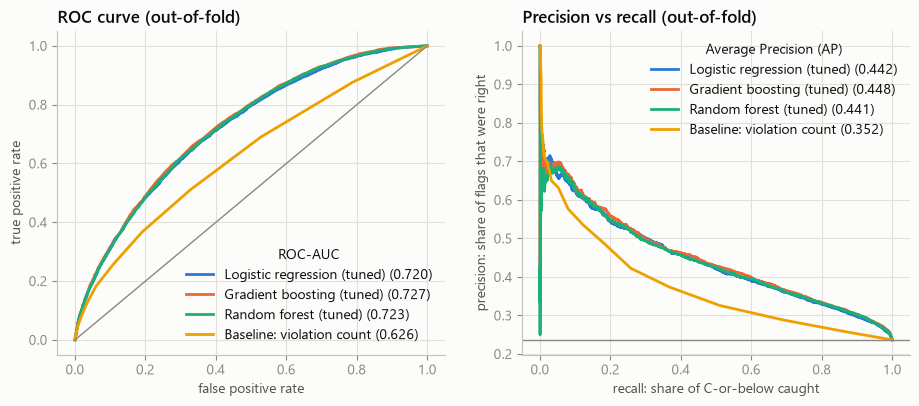

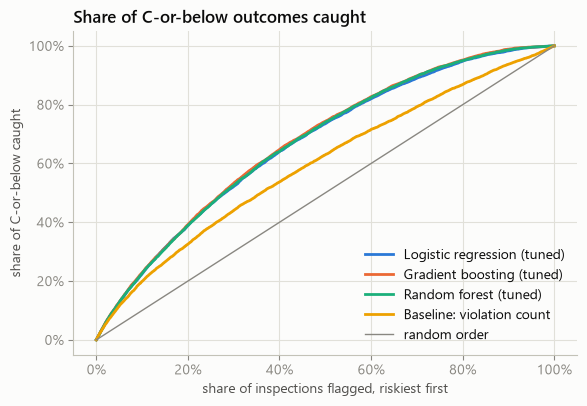

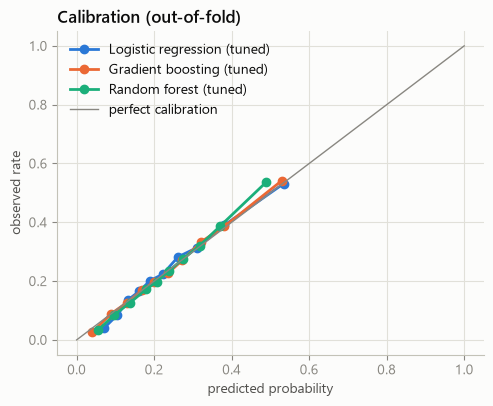

In [21]:
TUNED = ["Logistic regression (tuned)", "Gradient boosting (tuned)", "Random forest (tuned)"]
plot_curves(TUNED + ["Baseline: violation count"], "model_curves")
plot_capture(TUNED + ["Baseline: violation count"], "model_capture")
plot_calibration(TUNED, "model_calibration")  # the violation count isn't a probability

In [22]:
# Paired differences between the tuned candidates (same folds)
pairs = [(TUNED[0], TUNED[1]), (TUNED[0], TUNED[2]), (TUNED[1], TUNED[2]), (TUNED[0], "Baseline: violation count")]
pd.DataFrame([paired(a, b, metric) for a, b in pairs for metric in ["average_precision", "roc_auc"]]).round(4)

,mean difference,std of difference,folds where a is better
Logistic regression (tuned) vs Gradient boosting (tuned) (average_precision),-0.0067,0.0050,0.0
Logistic regression (tuned) vs Gradient boosting (tuned) (roc_auc),-0.0071,0.0022,0.0
Logistic regression (tuned) vs Random forest (tuned) (average_precision),-0.0008,0.0041,1.0
Logistic regression (tuned) vs Random forest (tuned) (roc_auc),-0.0035,0.0014,0.0
Gradient boosting (tuned) vs Random forest (tuned) (average_precision),0.0058,0.0051,4.0
Gradient boosting (tuned) vs Random forest (tuned) (roc_auc),0.0036,0.0023,5.0
Logistic regression (tuned) vs Baseline: violation count (average_precision),0.0897,0.0060,5.0
Logistic regression (tuned) vs Baseline: violation count (roc_auc),0.0944,0.0035,5.0


In [23]:
def probability_summary(y, p):
    """Spread of the individual predicted probabilities. The calibration plot shows only bin averages, so this adds
    the extremes and the top decile: its lowest prediction, its mean prediction and its observed rate."""
    y, p = np.asarray(y), np.asarray(p, dtype=float)
    top = p >= np.quantile(p, 0.9)
    return {"min": p.min(), "median": np.median(p), "99th percentile": np.quantile(p, 0.99), "max": p.max(),
            "share above 0.5": (p > 0.5).mean(), "top decile: lowest": p[top].min(),
            "top decile: mean predicted": p[top].mean(), "top decile: observed rate": y[top].mean()}


# Out-of-fold predicted probabilities of the tuned candidates (training rows)
pd.DataFrame({name: probability_summary(y_train, CV_RESULTS[name]["oof"]) for name in TUNED}).T.round(3)

,min,median,99th percentile,max,share above 0.5,top decile: lowest,top decile: mean predicted,top decile: observed rate
Logistic regression (tuned),0.017,0.206,0.668,0.983,0.054,0.427,0.534,0.530
Gradient boosting (tuned),0.013,0.219,0.660,0.838,0.055,0.430,0.529,0.541
Random forest (tuned),0.023,0.222,0.591,0.704,0.037,0.404,0.488,0.535


**How the candidates compare** (training rows, grouped 5-fold CV; development results, see section 9). The tables report the mean over the 5 folds; the curve legends show each metric on all out-of-fold predictions pooled, so they can differ slightly (gradient boosting's AP is 0.449 averaged over folds and 0.448 pooled).
- **Every model clears both baselines by a wide margin.** Tuned logistic regression beats the violation-count rule by +0.090 AP and +0.094 ROC-AUC, in every fold.
- **Tuned gradient boosting is best on both ranking metrics:** AP 0.449 and ROC-AUC 0.727. It beats tuned logistic regression in **all 5 folds** on both (+0.007 each), and the random forest in 4 of 5 (AP) and 5 of 5 (ROC-AUC). The gaps are small but consistent.
- **The tuning surface is flat.** All logistic-regression settings fall within 0.001 of each other. The best boosting settings all use very small trees (4 leaves) with 50+ inspections per leaf, so the gain over logistic regression comes from simple non-linear shapes and interactions (such as large venue × violations, EDA finding 6), not from deep trees.
- **Calibration, read carefully.** Each point on the calibration plot is the *average* predicted probability within one tenth of the inspections, plotted against that tenth's observed rate. For all three models these averages lie close to the diagonal, so where most predictions fall, predicted risk matches observed rates on average. The plot says nothing about individual predictions. The table above shows that every model makes some predictions well above the plot's top point (logistic regression's reach about 0.98), and that the top tenth spans a wide range of scores. Predictions that high are too few to check for calibration here. Brier scores (0.159–0.160, against 0.181 for the average-rate baseline) show better overall probability accuracy, but Brier mixes calibration with ranking, so it doesn't establish calibration by itself. In short, the probabilities are a reasonable guide to the average risk of a group of inspections, and a weaker guide for a single very high score.
- **Business view:** flagging the riskiest 20% of inspections catches about 39% of next-inspection C's with any of the three models, against 20% for random visits and 33% for ranking by violation count.

## 11. Choose the final model

**Final model: tuned gradient boosting.** It has 100 trees of 4 leaves each (learning rate 0.1, at least 100 inspections per leaf, L2 penalty 10) on 11 features.

The numbers below are development CV results. They're optimistic, because the same folds also guided feature selection, the feature-set choices and tuning (section 9), so they're used to choose a model, not to report its performance. Section 13's held-out restaurants give the principal final evaluation.
- **Primary metric:** best AP, 0.449 (fold std 0.013). It beats tuned logistic regression (0.442) in every fold, and the paired differences are steady (std 0.005), so the ranking of the two models isn't fold noise.
- **Secondary metrics:** also best on ROC-AUC (0.727), on capture in the top 10% and 20%, and on Brier score.
- **Calibration:** its bin averages track the diagonal as closely as logistic regression's. The caveats in section 10 about individual high predictions apply to all three models.
- **Explainability:** shallow trees on 11 named inputs, explained per restaurant with SHAP (section 14). That's less direct than coefficients, but enough to tell a stakeholder why a restaurant ranks high.
- **Complexity and maintenance:** a standard scikit-learn model with no text pipeline and no current-status inputs, trained in seconds.

**The trade-off:** the gain over logistic regression is small, about +0.007 on either metric and less than half a point of capture. Where transparency matters more than the last bit of ranking, for example a regulator who wants a points-style model, tuned logistic regression is the fallback: it loses very little, and its coefficients are shown in section 14 next to the SHAP view.

In [24]:
FINAL_NAME = 'Gradient boosting (tuned)'

**Earlier vs later period: a limited diagnostic.** The holdout measures unseen restaurants within 2020–2026, not a later period (02, section 2). This diagnostic stays inside the training rows. In each grouped fold, each candidate is refitted on the training restaurants' inspections **before** the median date, then scored on the held-out fold's inspections before that date (same period) and after it (later period). Both test sets are unseen restaurants, so the comparison isolates the inspection date.

In [25]:
CUTOFF = data.loc[is_train, TIME_COL].median()


def same_vs_later_period(name):
    """Mean fold scores of `name` fitted on the training restaurants' rows dated before CUTOFF and scored on the
    held-out fold's rows before it (same period) and after it (later period). Undated rows are in neither."""
    model, columns = CV_RESULTS[name]["model"], CV_RESULTS[name]["columns"] or FEATURES
    when = data.loc[is_train, TIME_COL].reset_index(drop=True)
    before, after = (when < CUTOFF).to_numpy(), (when >= CUTOFF).to_numpy()
    X = X_train[columns]
    rows = []
    for fit_idx, valid_idx in FOLDS:
        fit_rows = fit_idx[before[fit_idx]]
        fitted = clone(model).fit(X.iloc[fit_rows], y_train.iloc[fit_rows])
        for period, mask in [("same period", before), ("later period", after)]:
            scored = valid_idx[mask[valid_idx]]
            rows.append({"period": period, **score(y_train.iloc[scored], fitted.predict_proba(X.iloc[scored])[:, 1])})
    return pd.DataFrame(rows).groupby("period").mean()


print(f"fitted on training rows dated before {CUTOFF:%d %b %Y}; mean over the 5 grouped folds")
period_table = pd.concat({name: same_vs_later_period(name) for name in TUNED}, names=["model", "period"])
period_table[["roc_auc", "average_precision", "brier", "capture_top20"]].round(4)

fitted on training rows dated before 02 Jul 2023; mean over the 5 grouped folds


roc_auc  average_precision   brier  capture_top20
model                       period                                                         
Logistic regression (tuned) later period   0.7190             0.4384  0.1609         0.3876
                            same period    0.7198             0.4502  0.1602         0.3861
Gradient boosting (tuned)   later period   0.7259             0.4410  0.1597         0.3940
                            same period    0.7254             0.4515  0.1591         0.3872
Random forest (tuned)       later period   0.7235             0.4355  0.1607         0.3916
                            same period    0.7213             0.4478  0.1603         0.3860

**What the diagnostic shows, and what it doesn't.** Fitted on inspections before 2 July 2023, the chosen model ranks later-period inspections about as well as same-period ones (ROC-AUC 0.726 vs 0.725). AP is about 0.01 lower in the later period, and the other two candidates show the same small dip. So within 2020–2026 there's no sign of strong drift. The diagnostic has clear limits:
- the features and hyperparameters were chosen using the whole training period, including its later half, so this isn't a clean forward test;
- the dates when next-inspection outcomes became known aren't in the data, so a fit on "earlier" rows may still use labels that only became available later;
- like the grouped holdout, it covers only the observed date range.

It does **not** establish performance in a genuinely future deployment period. That needs prospective validation (scoring new inspections as they happen and comparing them with their outcomes) and ongoing monitoring, which are future work.

## 12. Decision threshold (training rows)

The cut-off comes from the **out-of-fold training predictions**, never from the holdout, and it's set by capacity, as section 2 framed it: loss control can act on a fixed share of restaurants. The working assumption is **the riskiest 20%**. That's roughly the share that will actually get a C (24%), so a perfect score would fill every visit with a future C. The table shows the trade-off at other capacities too.

In [26]:
def threshold_table(y, p, flag_shares=(0.05, 0.10, 0.20, 0.30)):
    """If we flag the top x% riskiest inspections: the score cut-off, and the precision / recall of those flags."""
    y, p = np.asarray(y), np.asarray(p)
    rows = []
    for flag_share in flag_shares:
        cut = np.quantile(p, 1 - flag_share)
        flagged = p >= cut
        rows.append({"flag_share": flag_share, "threshold": cut, "flagged": int(flagged.sum()),
                     "precision": y[flagged].mean(), "recall": y[flagged].sum() / y.sum()})
    return pd.DataFrame(rows)


FLAG_SHARE = 0.20  # capacity assumed in section 2: visit the riskiest 20% first
display(threshold_table(y_train, CV_RESULTS[FINAL_NAME]["oof"]).round(3))
THRESHOLD = float(np.quantile(CV_RESULTS[FINAL_NAME]["oof"], 1 - FLAG_SHARE))
print(f"THRESHOLD = {THRESHOLD:.3f}: flag an inspection when its predicted probability is at least this")

,flag_share,threshold,flagged,precision,recall
0,0.05,0.509,1403,0.608,0.129
1,0.10,0.430,2804,0.541,0.229
2,0.20,0.348,5608,0.464,0.392
3,0.30,0.294,8427,0.420,0.533


THRESHOLD = 0.348: flag an inspection when its predicted probability is at least this


## 13. Final test on the holdout (run once)

The final model is refit on all training rows and scored on the holdout. If the holdout scores are close to the cross-validation scores, the estimate is trustworthy, and that's what you quote in the report and the deck.

In [27]:
if FINAL_NAME is None:
    print("Set FINAL_NAME in section 11 first.")
else:
    final_columns = CV_RESULTS[FINAL_NAME]["columns"] or FEATURES
    final_model = clone(CV_RESULTS[FINAL_NAME]["model"]).fit(X_train[final_columns], y_train)
    p_hold = final_model.predict_proba(X_hold[final_columns])[:, 1]
    holdout_scores = pd.Series(score(y_hold, p_hold), name="holdout")
    cv_scores = CV_RESULTS[FINAL_NAME]["folds"].mean().rename("cross-validation (train)")
    display(pd.concat([cv_scores, holdout_scores], axis=1).round(4))
    if THRESHOLD is not None:
        flagged = p_hold >= THRESHOLD
        print(f"At threshold {THRESHOLD:.3f}: flags {flagged.mean():.1%} of holdout inspections, "
              f"precision {y_hold[flagged].mean():.1%}, recall {y_hold[flagged].sum() / y_hold.sum():.1%}")

,cross-validation (train),holdout
roc_auc,0.7271,0.7289
average_precision,0.4488,0.4530
brier,0.1589,0.1559
capture_top10,0.2292,0.2388
capture_top20,0.3922,0.4138


At threshold 0.348: flags 20.7% of holdout inspections, precision 47.0%, recall 42.1%


In [28]:
# Holdout predicted probabilities, and calibration by decile on these unseen restaurants (evaluation only)
display(pd.DataFrame({"final model, holdout": probability_summary(y_hold, p_hold)}).T.round(3))
decile = pd.qcut(p_hold, 10, labels=False, duplicates="drop") + 1
(pd.DataFrame({"decile": decile, "predicted": p_hold, "observed": y_hold.to_numpy()})
 .groupby("decile").agg(rows=("observed", "size"), lowest=("predicted", "min"), highest=("predicted", "max"),
                        mean_predicted=("predicted", "mean"), observed_rate=("observed", "mean")).round(3))

,min,median,99th percentile,max,share above 0.5,top decile: lowest,top decile: mean predicted,top decile: observed rate
"final model, holdout",0.013,0.218,0.65,0.807,0.053,0.43,0.519,0.557


,rows,lowest,highest,mean_predicted,observed_rate
decile,,,,,
1,734,0.013,0.071,0.042,0.046
2,659,0.071,0.111,0.091,0.077
3,701,0.111,0.151,0.133,0.121
4,702,0.151,0.185,0.168,0.158
5,686,0.185,0.218,0.200,0.181
6,697,0.218,0.254,0.238,0.228
7,712,0.254,0.295,0.274,0.272
8,685,0.295,0.348,0.322,0.276
9,692,0.348,0.430,0.382,0.405


**Holdout result: the principal final evaluation.** The held-out restaurants were first scored after every choice above was fixed, and later re-runs only reproduce the same numbers. So these results aren't influenced by any modeling decision, and they're the ones to report. They're close to the development CV results, and slightly better on every metric: ROC-AUC 0.729 vs 0.727, AP 0.453 vs 0.449, Brier 0.156 vs 0.159. That suggests the optimism from reusing the folds for selection and tuning was small here, but the holdout remains the estimate to quote.

On 3,981 restaurants the model never saw (6,964 inspections, 23.1% followed by a C or below), two ways of building a 20% visit list give slightly different numbers:
- **exactly the highest-scoring 20%** of holdout inspections would catch 41.4% of the C's (`capture_top20`);
- **the fixed threshold derived from training** (0.348) flags 20.7% of holdout inspections, catching 42.1% of the C's (recall), and 47.0% of its flags are right (precision).

Random visits of the same size would catch about 20–21% of the C's and be right 23% of the time, so the model roughly doubles the hit rate of a visit list. In the decile table above, each tenth of the holdout's mean prediction is within about 3 points of its observed rate in 9 of 10 deciles. The largest gap is the 8th decile (0.32 predicted vs 0.28 observed), and each decile has only about 700 inspections, so some deviation is expected. The section 10 caveats about individual high predictions still apply: the top decile runs from 0.43 to 0.81.

## 14. What drives the predictions

For the deck: which inputs push risk up or down. Use coefficients for logistic regression and SHAP for any model. Translate the top drivers into plain language.

first_violation_demerits    0.507
large_venue                 0.429
n_violations                0.262
positive_note               0.180
pest_note                   0.136
sewage_note                 0.125
critical_count              0.020
is_buffet                   0.009
critical_item_note          0.004
worst_severity_rank         0.001
ihh_present                 0.001
Name: mean |SHAP|, dtype: float64

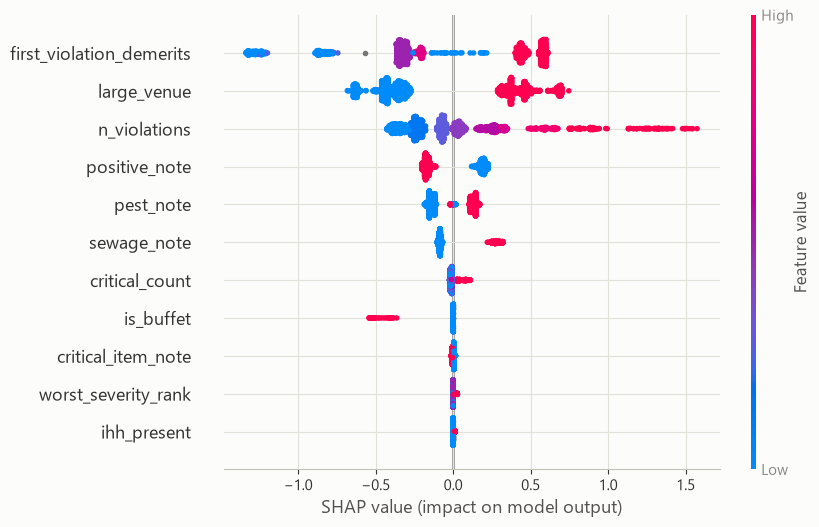

In [29]:
def readable(names):
    """Preprocessed column names for people: 'num__large_venue' -> 'large_venue', 'text__pest' -> 'notes: "pest"'."""
    out = []
    for name in names:
        part, _, rest = name.partition("__")
        out.append(f'notes: "{rest}"' if part == "text" else rest)
    return out


def coefficient_table(fitted_pipeline):
    """Logistic-regression coefficients on the preprocessed inputs, largest effect first. Numeric inputs are
    standardized, so each coefficient is the change in log-odds for one standard deviation."""
    names = readable(fitted_pipeline[:-1].get_feature_names_out())
    table = pd.DataFrame({"feature": names, "coef": fitted_pipeline[-1].coef_[0]})
    table["odds ratio"] = np.exp(table["coef"])
    return table.reindex(table["coef"].abs().sort_values(ascending=False).index).reset_index(drop=True)


def shap_summary(fitted_pipeline, X, sample=2000, max_display=15, file_name=None):
    """SHAP beeswarm for a fitted Pipeline(prep -> model): which inputs push predictions up or down, and how much."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # shap imports tqdm, which warns that Jupyter widgets are missing
        import shap
    rows = X.sample(min(sample, len(X)), random_state=RANDOM_STATE)
    prep, model = fitted_pipeline[:-1], fitted_pipeline[-1]
    Xt = prep.transform(rows)
    Xt = pd.DataFrame(Xt.toarray() if hasattr(Xt, "toarray") else Xt, columns=readable(prep.get_feature_names_out()),
                      index=rows.index)
    explanation = shap.Explainer(model, Xt)(Xt)
    if explanation.values.ndim == 3:  # some models return one set of values per class
        explanation = explanation[:, :, 1]
    plt.figure()  # beeswarm draws on the current figure, so start a fresh one
    shap.plots.beeswarm(explanation, max_display=max_display, show=False)
    if file_name:
        save_fig(plt.gcf(), file_name)
    return explanation


explanation = shap_summary(final_model, X_train[final_columns], file_name="model_shap")
importance = pd.Series(np.abs(explanation.values).mean(axis=0), index=explanation.feature_names, name="mean |SHAP|")
importance.sort_values(ascending=False).head(15).round(3)

In [30]:
# The fallback model's coefficients (section 11): the most direct view of each input's direction and size
FALLBACK = "Logistic regression (tuned)"
lr_model = (final_model if isinstance(final_model[-1], LogisticRegression)
            else clone(CV_RESULTS[FALLBACK]["model"]).fit(X_train[CV_RESULTS[FALLBACK]["columns"]], y_train))
coefficient_table(lr_model).round(3)

,feature,coef,odds ratio
0,large_venue,0.364,1.440
1,first_violation_demerits,0.344,1.411
2,n_violations,0.328,1.388
3,positive_note,-0.195,0.823
4,sewage_note,0.152,1.164
5,pest_note,0.136,1.146
6,critical_item_note,0.095,1.099
7,critical_count,0.083,1.087
8,ihh_present,0.079,1.082
9,is_buffet,-0.074,0.929


**What drives the predictions** (SHAP on 2,000 training inspections). The fallback model's coefficients agree on the direction of every input with a meaningful effect.
1. **The first violation's demerits** (the largest effect). When the first code on the report carries high demerits (a critical item, 5 or more), risk goes up; a low-demerit first code pushes it down. As 03 noted, why the *first* code matters beyond the overall counts isn't documented, but the direction is the sensible one.
2. **Venue size.** More than 200 seats raises risk, on top of everything else.
3. **The number of violations.** Risk rises steadily with the count, and the biggest single pushes in the data come from inspections with many violations.
4. **The inspector's notes.** Praise of the condition ("spotless prep area", "temperatures all in range") lowers risk; pest and sewage notes raise it.
5. **Smaller effects:** buffets are lower risk, and the critical count adds a little. Worst severity, the IHH flag and the critical-item note add almost nothing once the inputs above are known, because their information overlaps the first violation's demerits and the counts.

In plain words for stakeholders: *a restaurant is most likely to fail its next inspection when this inspection found many violations led by a serious one, it's a large venue, and the inspector noted pests or sewage instead of praising the kitchen.*

## 15. Readiness checklist and save

`final_model.joblib` is fitted on the training rows, which matches the reported results. Refitting on all rows before deployment is common practice; mention it as a next step.

**What the checks below can and can't establish.** They inspect the split, the folds, the pipelines and the fitted model directly. They can't verify *when* each value was recorded, because the dataset has no such timestamps. These timing assumptions remain, documented rather than proven:
- The model's inputs (the violation list and its first code, seating capacity, category, and the inspector's notes) are assumed to be recorded at or before this inspection.
- Restaurant attributes such as seating capacity and category are assumed stable. If they were updated after the inspection, they could carry later information.
- The label describes the next inspection, whose date is unknown. So it can't be confirmed when each outcome became known, or that it came after everything the inputs record.
- `CURRENT_GRADE` and `CURRENT_DEMERITS` may postdate the inspection. They're excluded from the final model, which the last check confirms.

In [31]:
FORBIDDEN_INPUTS = {TARGET, GROUP_KEY, TIME_COL, "split", "RESTAURANT_PERMIT_NUMBER", "RESTAURANT_NAME",
                    "RECORD_UPDATED", "CURRENT_GRADE", "CURRENT_DEMERITS", "current_grade_rank", "current_demerits"}


def passes(check):
    """Run one check; an error counts as a failure, so the checklist itself never raises."""
    try:
        return bool(check())
    except Exception:
        return False


def leakage_checks():
    """Checks that inspect the split, the folds, the pipelines and the fitted final model directly."""
    inputs = lambda: list(final_model.feature_names_in_)
    oof = lambda: CV_RESULTS[FINAL_NAME]["oof"]
    candidates = lambda: [r["model"] for n, r in CV_RESULTS.items() if not n.startswith("Baseline")]
    current_status = lambda: (set(dictionary.loc[dictionary["feature_set"].eq("current_status"), "feature"])
                              | {"CURRENT_GRADE", "CURRENT_DEMERITS"})
    return {
        "no restaurant in both training and holdout":
            lambda: not set(data.loc[is_train, GROUP_KEY]) & set(data.loc[~is_train, GROUP_KEY]),
        "no restaurant in both the fitting and the validation part of any CV fold":
            lambda: all(not set(g_train.iloc[fit]) & set(g_train.iloc[valid]) for fit, valid in FOLDS),
        "every training row is predicted out-of-fold exactly once":
            lambda: np.array_equal(np.sort(np.concatenate([valid for _, valid in FOLDS])), np.arange(len(X_train))),
        "no target, identifier, date or post-inspection field among the final model's inputs":
            lambda: not set(inputs()) & FORBIDDEN_INPUTS,
        "no single input nearly reproduces the target (training ROC-AUC between 0.02 and 0.98)":
            lambda: all(0.02 < roc_auc_score(y_train, X_train[c].fillna(X_train[c].median())) < 0.98 for c in inputs()),
        "every candidate is a pipeline whose preprocessing is fitted per fold (stored unfitted, cloned for each fit)":
            lambda: all(isinstance(m, Pipeline) and isinstance(m.steps[0][1], ColumnTransformer)
                        and not hasattr(m.steps[0][1], "transformers_") for m in candidates()),
        "inputs reach the pipelines untransformed (missing values and raw counts still present)":
            lambda: X_train[NUMERIC].isna().any().any() and X_train["n_violations"].max() > 10,
        "threshold equals the training out-of-fold quantile for the flag share":
            lambda: len(oof()) == len(y_train) and THRESHOLD == float(np.quantile(oof(), 1 - FLAG_SHARE)),
        "final model's inputs match its CV run and are all kept features":
            lambda: inputs() == list(CV_RESULTS[FINAL_NAME]["columns"]) and set(inputs()) <= set(kept["feature"]),
        "final model excludes CURRENT_GRADE / CURRENT_DEMERITS and their features":
            lambda: not set(inputs()) & current_status(),
    }


def readiness_checks():
    """Pass/fail for each modeling goal, then the leakage checks; never raises."""
    candidates = [n for n in CV_RESULTS if not n.startswith("Baseline")]
    goals = {
        "at least two candidate models cross-validated": lambda: len(candidates) >= 2,
        "final model chosen and beats every baseline on the primary metric (CV)": lambda: (
            CV_RESULTS[FINAL_NAME]["folds"][PRIMARY_METRIC].mean()
            > max(CV_RESULTS[n]["folds"][PRIMARY_METRIC].mean() for n in CV_RESULTS if n.startswith("Baseline"))),
        "holdout scored on every metric": lambda: len(p_hold) == len(X_hold)
                                                  and list(holdout_scores.index) == list(cv_scores.index),
        "model figures saved": lambda: all((FIG / f"model_{n}.png").exists()
                                           for n in ["curves", "capture", "calibration", "shap"]),
    }
    results = {name: passes(check) for name, check in {**goals, **leakage_checks()}.items()}
    for name, ok in results.items():
        print(("✅ " if ok else "❌ ") + name)
    return all(results.values())


all_passed = readiness_checks()

✅ at least two candidate models cross-validated
✅ final model chosen and beats every baseline on the primary metric (CV)
✅ holdout scored on every metric
✅ model figures saved
✅ no restaurant in both training and holdout
✅ no restaurant in both the fitting and the validation part of any CV fold
✅ every training row is predicted out-of-fold exactly once
✅ no target, identifier, date or post-inspection field among the final model's inputs
✅ no single input nearly reproduces the target (training ROC-AUC between 0.02 and 0.98)
✅ every candidate is a pipeline whose preprocessing is fitted per fold (stored unfitted, cloned for each fit)
✅ inputs reach the pipelines untransformed (missing values and raw counts still present)
✅ threshold equals the training out-of-fold quantile for the flag share
✅ final model's inputs match its CV run and are all kept features
✅ final model excludes CURRENT_GRADE / CURRENT_DEMERITS and their features


In [32]:
SAVE_ANYWAY = False

if all_passed or SAVE_ANYWAY:
    MODELS.mkdir(exist_ok=True)
    comparison_table().to_csv(MODELS / "cv_results.csv", index_label="model")
    if "holdout_scores" in globals():
        holdout_scores.to_csv(MODELS / "holdout_results.csv", header=True)
        joblib.dump(final_model, MODELS / "final_model.joblib")
        info = {"final_model": FINAL_NAME, "features": list(final_columns), "threshold": THRESHOLD,
                "flag_share": FLAG_SHARE, "primary_metric": PRIMARY_METRIC,
                "cross_validation": cv_scores.round(4).to_dict(), "holdout": holdout_scores.round(4).to_dict(),
                "fitted_on": "training rows only (holdout: 20% of restaurants, grouped, see 02)"}
        (MODELS / "final_model_info.json").write_text(json.dumps(info, indent=2))
    print("saved to", MODELS)
else:
    print("Not saved: finish the failing checks above, or set SAVE_ANYWAY = True.")

saved to C:\Users\19176\las-vegas-restaurant-inspections\models


In [33]:
# Reload check: the saved model and its metadata reproduce the in-memory model exactly
if (MODELS / "final_model.joblib").exists():
    reloaded = joblib.load(MODELS / "final_model.joblib")
    saved_info = json.loads((MODELS / "final_model_info.json").read_text())
    reload_checks = {
        "reloaded model gives identical holdout predictions":
            np.array_equal(reloaded.predict_proba(X_hold[final_columns])[:, 1], p_hold),
        "reloaded model gives identical training predictions":
            np.array_equal(reloaded.predict_proba(X_train[final_columns])[:, 1],
                           final_model.predict_proba(X_train[final_columns])[:, 1]),
        "saved metadata lists the model's input columns, in order":
            saved_info["features"] == list(reloaded.feature_names_in_),
        "saved metadata threshold equals the training-derived threshold": saved_info["threshold"] == THRESHOLD,
    }
    for name, ok in reload_checks.items():
        print(("✅ " if ok else "❌ ") + name)

✅ reloaded model gives identical holdout predictions
✅ reloaded model gives identical training predictions
✅ saved metadata lists the model's input columns, in order
✅ saved metadata threshold equals the training-derived threshold
